# 23B Neuron to Premotor Connectivity

In this notebook we'll take a look at how information flows downstream of 23B neurons with a focus on how that information get to motor neurons.

In [1]:
from caveclient import CAVEclient
import pandas as pd
import numpy as np 
from nglui.statebuilder import *
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
syn_df = pd.read_parquet('../data/23B_downstream_synapses.parquet')
targets = syn_df.post_pt_root_id.unique()

Let's get all the premotor neurons by querying for all the upstream targets of motor neurons

In [8]:
dataset = 'fanc_production_mar2021'
client = CAVEclient(dataset)

In [9]:
#Loading the motor neuron data
mndf = client.materialize.query_table('all_leg_motor_neuron_table_v0')
mndf['segment'] = mndf.classification_system.apply(lambda x: x.split('_')[1])
mndf.segment.value_counts()


module = client.materialize.query_table('leg_mn_module_reftable_v0')
module_dict = dict(zip(module.pt_root_id.tolist(),module.tag.tolist()))

mndf['module'] = mndf.pt_root_id.map(module_dict)

Table Owner Notice on soma_jan2022: Newer version of soma table is available. See client.info.get_datastack_info()['soma_table'], Using non-pandas query execution is deprecated as it can mangle types, please upgrade caveclient to >=8.0.0 to use pandas for improved type handling.
Using non-pandas query execution is deprecated as it can mangle types, please upgrade caveclient to >=8.0.0 to use pandas for improved type handling.


In [10]:
targets = targets[~np.isin(targets, mndf.pt_root_id.unique())]

In [11]:
#Grabbing all the premotor neuron objects in the VNC

#Upstream synapse table
t1r_ids = mndf.query('segment == "T1R"').pt_root_id.unique()
up_t1r_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t1r_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)

#Upstream synapse table
t1l_ids = mndf.query('segment == "T1L"').pt_root_id.unique()
up_t1l_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t1l_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [12]:
#Upstream synapse table
t2r_ids = mndf.query('segment == "T2R"').pt_root_id.unique()
up_t2r_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t2r_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)
#Upstream synapse table
t2l_ids = mndf.query('segment == "T2L"').pt_root_id.unique()
up_t2l_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t2l_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [13]:
#Upstream synapse table
t3r_ids = mndf.query('segment == "T3R"').pt_root_id.unique()
up_t3r_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t3r_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)
#Upstream synapse table
t3l_ids = mndf.query('segment == "T3L"').pt_root_id.unique()
up_t3l_df = client.materialize.synapse_query(pre_ids=targets, post_ids = t3l_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [14]:
wing_df = client.materialize.query_table('wing_motor_neuron_table_v0')
wing_df['segment'] = ['Wing_L' if '_L' in i else 'Wing_R' for i in wing_df.classification_system]

#Upstream synapse table
wing_r_ids = wing_df.query('segment == "Wing_R"').pt_root_id.unique()
up_wing_r_df = client.materialize.synapse_query(pre_ids=targets, post_ids = wing_r_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)
#Upstream synapse table
wing_l_ids = wing_df.query('segment == "Wing_L"').pt_root_id.unique()
up_wing_l_df = client.materialize.synapse_query(pre_ids=targets, post_ids = wing_l_ids, 
                                                    synapse_table = 'synapses_nov2022',
                                                    split_positions = True)

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [15]:
#Concatenating all the premotor neurons ids together
pm_t1l = up_t1l_df.pre_pt_root_id.unique().tolist()
pm_t1r = up_t1r_df.pre_pt_root_id.unique().tolist()

pm_t2l = up_t2l_df.pre_pt_root_id.unique().tolist()
pm_t2r = up_t2r_df.pre_pt_root_id.unique().tolist()

pm_t3l = up_t3l_df.pre_pt_root_id.unique().tolist()
pm_t3r = up_t3r_df.pre_pt_root_id.unique().tolist()

pm_wing_l = up_wing_l_df.pre_pt_root_id.unique().tolist()
pm_wing_r = up_wing_r_df.pre_pt_root_id.unique().tolist()

pm_all = pm_t1l + pm_t1r + pm_t2l + pm_t1r + pm_t3l + pm_t3r + pm_wing_l + pm_wing_r

In [16]:
#Mapping Premotor label to postsynaptic targets in the synapse table
syn_df['is_vnc_pm'] = syn_df.post_pt_root_id.isin(pm_all)

syn_df['is_t1l_pm'] = syn_df.post_pt_root_id.isin(pm_t1l)
syn_df['is_t1r_pm'] = syn_df.post_pt_root_id.isin(pm_t1r)

syn_df['is_t2l_pm'] = syn_df.post_pt_root_id.isin(pm_t2l)
syn_df['is_t2r_pm'] = syn_df.post_pt_root_id.isin(pm_t2r)

syn_df['is_t3l_pm'] = syn_df.post_pt_root_id.isin(pm_t3l)
syn_df['is_t3r_pm'] = syn_df.post_pt_root_id.isin(pm_t3r)

syn_df['is_wingl_pm'] = syn_df.post_pt_root_id.isin(pm_wing_l)
syn_df['is_wingr_pm'] = syn_df.post_pt_root_id.isin(pm_wing_r)

### Let's take a look at how often 23B neurons contact motor neurons and premotor neurons.

In [17]:
# Group by pre_pt_root_id and count the total number of synapses
total_synapse_counts = syn_df.groupby('pre_pt_root_id').size()

# Count the number of premotor synapses per pre_pt_root_id
premotor_synapse_counts = syn_df[syn_df['is_vnc_pm']].groupby('pre_pt_root_id').size()

# Convert to DataFrames for better readability
total_synapse_counts_df = total_synapse_counts.reset_index(name='total_synapse_count')
premotor_synapse_counts_df = premotor_synapse_counts.reset_index(name='premotor_synapse_count')

# Merge the two DataFrames
synapse_counts_df = pd.merge(total_synapse_counts_df, premotor_synapse_counts_df, on='pre_pt_root_id', how='left')

# Fill NaN values in premotor_synapse_count with 0 (for pre_pt_root_id with no premotor synapses)
synapse_counts_df['premotor_synapse_count'] = synapse_counts_df['premotor_synapse_count'].fillna(0).astype(int)
synapse_counts_df['prop_premotor_synapses'] = synapse_counts_df['premotor_synapse_count'] / synapse_counts_df['total_synapse_count']
synapse_counts_df.head()


,pre_pt_root_id,total_synapse_count,premotor_synapse_count,prop_premotor_synapses
0,648518346465093237,247,187,0.757085
1,648518346465296501,481,374,0.777547
2,648518346467135470,614,423,0.688925
3,648518346472624690,1410,957,0.678723
4,648518346472643787,308,231,0.750000


In [18]:
# Count the number of premotor synapses per pre_pt_root_id
motor_synapse_counts = syn_df[syn_df['is_mn']].groupby('pre_pt_root_id').size()

# Convert to DataFrames for better readability
motor_synapse_counts_df = motor_synapse_counts.reset_index(name='motor_synapse_count')


# Fill NaN values in premotor_synapse_count with 0 (for pre_pt_root_id with no premotor synapses)
synapse_counts_df['motor_synapse_count'] = motor_synapse_counts_df['motor_synapse_count'].fillna(0).astype(int)
synapse_counts_df['prop_motor_synapses'] = motor_synapse_counts_df['motor_synapse_count'] / synapse_counts_df['total_synapse_count']
synapse_counts_df['prop_motor_synapses'].fillna(0, inplace=True)

In [19]:
label_dict = dict(zip(syn_df.pre_pt_root_id.tolist(), syn_df['23B_label'].tolist()))
synapse_counts_df['label'] = synapse_counts_df.pre_pt_root_id.map(label_dict)

In [20]:
palette = sns.color_palette("YlOrRd", 20)
color_dict = {
 'Asc.':'#CC0468',#fb8239',
 'Mid. Dorsal':'#FF69B4',#ee3e03',
 'Dorsal':"#FFB6C1",
 'Mid. Inter.':"#FFDAB9",
 'Mid.':palette[3],
 'Contra. Inter.':palette[5],
 'Ipsi. T1':'#FFA500',
 'Contra. T1':'#fb8239', 
 'Contra. T2':palette[12],
 'Ipsi. T3':"#F57B6B",
 'Ant.':palette[15],
 'Ipsi. Wing':palette[19],
 'Contra. Wing':"#4B0101"
}

order_dict = {
 'Asc.':1,
 'Mid. Dorsal':2,
 'Dorsal':3,
 'Mid. Inter.':4,
 'Mid.':5,
 'Contra. Inter.':6,
 'Ipsi. T1':7,
 'Contra. T1':8,
 'Contra. T2':9,
 'Ipsi. T3':10,
 'Ant.':11,
 'Ipsi. Wing':12,
 'Contra. Wing':13
}

synapse_counts_df['label_order'] = synapse_counts_df['label'].map(order_dict)
synapse_counts_df = synapse_counts_df.sort_values(['label_order', 'prop_premotor_synapses'])
synapse_counts_df['order'] = np.arange(len(synapse_counts_df))
#synapse_counts_df = synapse_counts_df[synapse_counts_df['23B_label']!='t3l']
synapse_counts_df.head()

,pre_pt_root_id,total_synapse_count,premotor_synapse_count,prop_premotor_synapses,motor_synapse_count,prop_motor_synapses,label,label_order,order
54,648518346504278624,313,231,0.738019,NaN,0.000000,Asc.,1,0
3,648518346472624690,1410,957,0.678723,1.0,0.000709,Mid. Dorsal,2,1
5,648518346473251684,1225,975,0.795918,149.0,0.121633,Dorsal,3,2
27,648518346490903725,888,713,0.802928,NaN,0.000000,Dorsal,3,3
26,648518346490574940,1209,1018,0.842018,NaN,0.000000,Dorsal,3,4


Here is the proportion of 23B connectivity onto premotor neurons ordered by 23B subtype

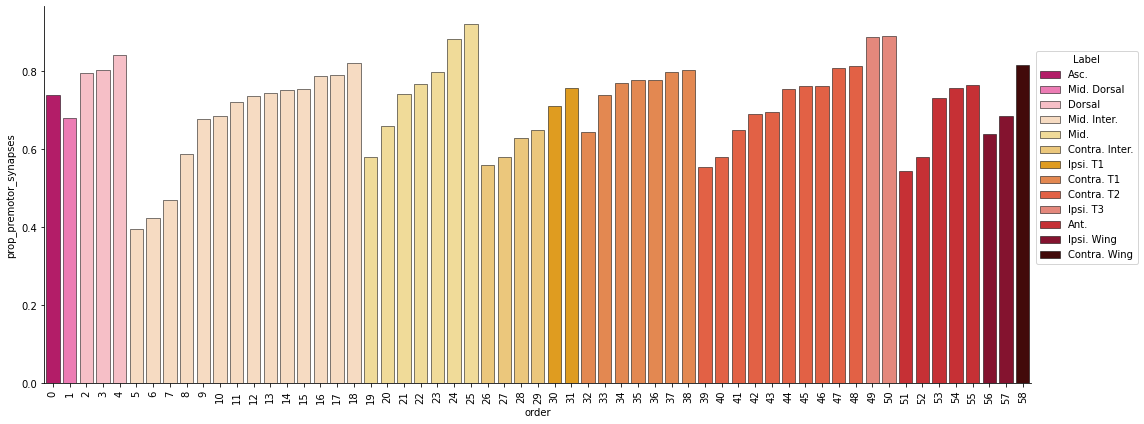

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
plt.xticks(rotation=90)
sns.barplot(data=synapse_counts_df,
            x='order',
            y='prop_premotor_synapses',
            hue='label', dodge=False,
            palette=color_dict,
            hue_order=synapse_counts_df.label.unique(),
            edgecolor='black',
            linewidth=0.5)

sns.despine(ax=ax, top=True, right=True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.6), title='Label')
plt.tight_layout()


How does this compare to motor neuron connectivity?

/Users/leilae/anaconda3/envs/flymoves/lib/python3.7/site-packages/seaborn/relational.py:608: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scout = ax.scatter(scout_x, scout_y, **kws)
/Users/leilae/anaconda3/envs/flymoves/lib/python3.7/site-packages/seaborn/relational.py:658: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(*args, **kws)
No handles with labels found to put in legend.


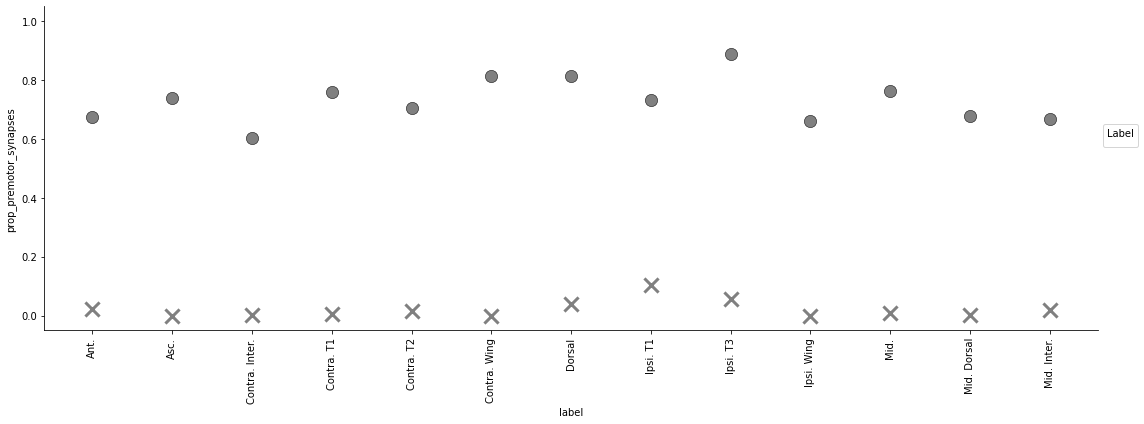

In [22]:
fig, ax = plt.subplots(figsize=(16, 6))
plt.xticks(rotation=90)

# Calculate the mean prop_premotor_synapses for each label
mean_prop_premotor_synapses = synapse_counts_df.groupby('label')['prop_premotor_synapses'].mean().reset_index()

# Update the scatterplot data to use the mean values
sns.scatterplot(data=mean_prop_premotor_synapses,
                x='label',
                y='prop_premotor_synapses',
                color='gray', 
                s=150,
                palette=color_dict,
                edgecolor='black',
                linewidth=0.5)

# Calculate the mean prop_premotor_synapses for each label
mean_prop_motor_synapses = synapse_counts_df.groupby('label')['prop_motor_synapses'].mean().reset_index()

# Update the scatterplot data to use the mean values

sns.scatterplot(data=mean_prop_motor_synapses,
                x='label',
                y='prop_motor_synapses',
                marker='x', 
                color='gray', 
                s=200,
                palette=color_dict,
                edgecolor='black',
                linewidth=3)

sns.despine(ax=ax, top=True, right=True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.6), title='Label')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()

# figname = '23b_proportion_premotor_motor_output.eps'
# fig_path = os.path.join(output_folder,figname)   
# plt.savefig(fig_path)

Since our behavior of interest involves the two front legs and the middle left leg, we will focus our analysis on only the premotor neurons in those three leg neuropil.

In [23]:
subset = syn_df.query('is_t1l_pm == True | is_t2l_pm == True | is_t1r_pm == True')

neuropil = []
for i in subset.post_pt_root_id:
    if i in pm_t1l:
        neuropil.append('T1L')
    elif i in pm_t1r:
        neuropil.append('T1R')
    elif i in pm_t2l: 
        neuropil.append('T2L')
    else:
        neuropil.append('other')
subset['neuropil'] = neuropil

subset = subset.query('segment_count == 1').groupby(['23B_label','pre_pt_root_id','neuropil']).size().reset_index(name='count')
subset = subset.query('count > 3')
subset = subset[subset['23B_label']!= "t3l"]
#subset = subset[subset['23B_label']!= "wing_r"]

subset['pm_total'] = subset.groupby('pre_pt_root_id')['count'].transform('sum')
subset['neuropil_weight'] = subset['count'] / subset['pm_total']
subset.head()

/Users/leilae/anaconda3/envs/flymoves/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]


,23B_label,pre_pt_root_id,neuropil,count,pm_total,neuropil_weight
0,Ant.,648518346465093237,T1L,112,112,1.000000
1,Ant.,648518346480536790,T1L,85,93,0.913978
2,Ant.,648518346480536790,T2L,8,93,0.086022
3,Ant.,648518346483024102,T1L,21,21,1.000000
4,Ant.,648518346490410193,T1L,36,36,1.000000


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


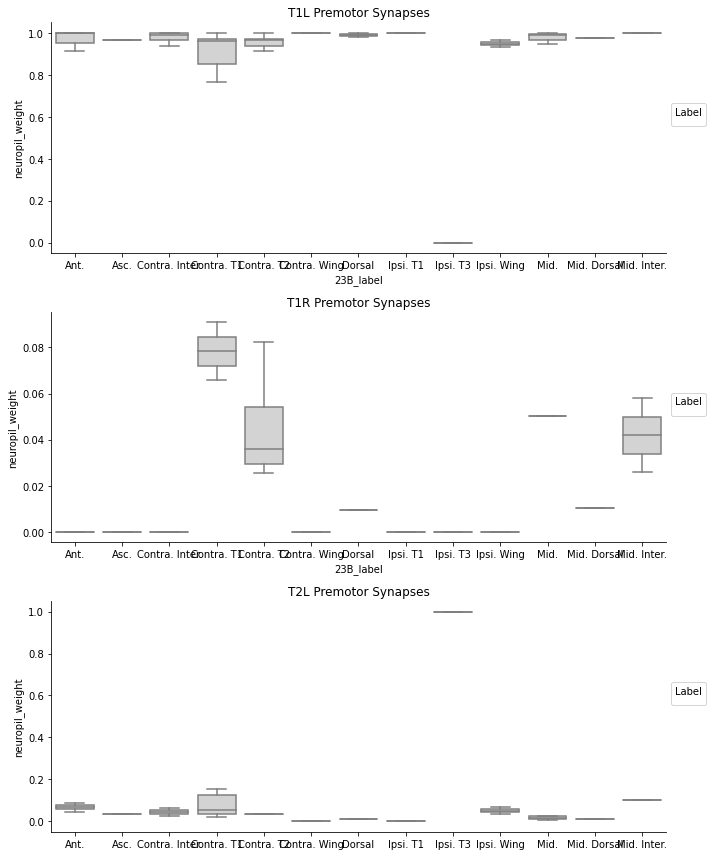

In [24]:
fig, ax = plt.subplots(3,1,figsize=(10, 12),gridspec_kw={'height_ratios': [1, 1, 1]})

# Ensure every 23B_label is represented in all three plots
all_labels = subset['23B_label'].unique()
for neuropil in ['T1L', 'T1R', 'T2L']:
    missing_labels = set(all_labels) - set(subset.query(f'neuropil=="{neuropil}"')['23B_label'])
    for label in missing_labels:
        subset = pd.concat([subset, pd.DataFrame({'23B_label': [label], 'neuropil': [neuropil], 'neuropil_weight': [0]})])
        
sns.boxplot(data=subset.query('neuropil=="T1L"').sort_values('23B_label'),x='23B_label',y='neuropil_weight', 
            showfliers=False,ax=ax[0],color='lightgray')
ax[0].set_title('T1L Premotor Synapses')
#ax[0].set_ylim(-0.02,1.02)
sns.boxplot(data=subset.query('neuropil=="T1R"').sort_values('23B_label'),x='23B_label',y='neuropil_weight', 
            showfliers=False,ax=ax[1],color='lightgray')
ax[1].set_title('T1R Premotor Synapses')
#ax[1].set_ylim(-0.02,0.13)

sns.boxplot(data=subset.query('neuropil=="T2L"').sort_values('23B_label'),x='23B_label',y='neuropil_weight',
            showfliers=False,ax=ax[2],color='lightgray')
ax[2].set_title('T2L Premotor Synapses')
ax[2].set_xlabel('')


for ix, ax_i in enumerate(ax):
    sns.despine(ax=ax_i, top=True, right=True)
    ax_i.legend(loc='center left', bbox_to_anchor=(1, 0.6), title='Label')
plt.tight_layout()

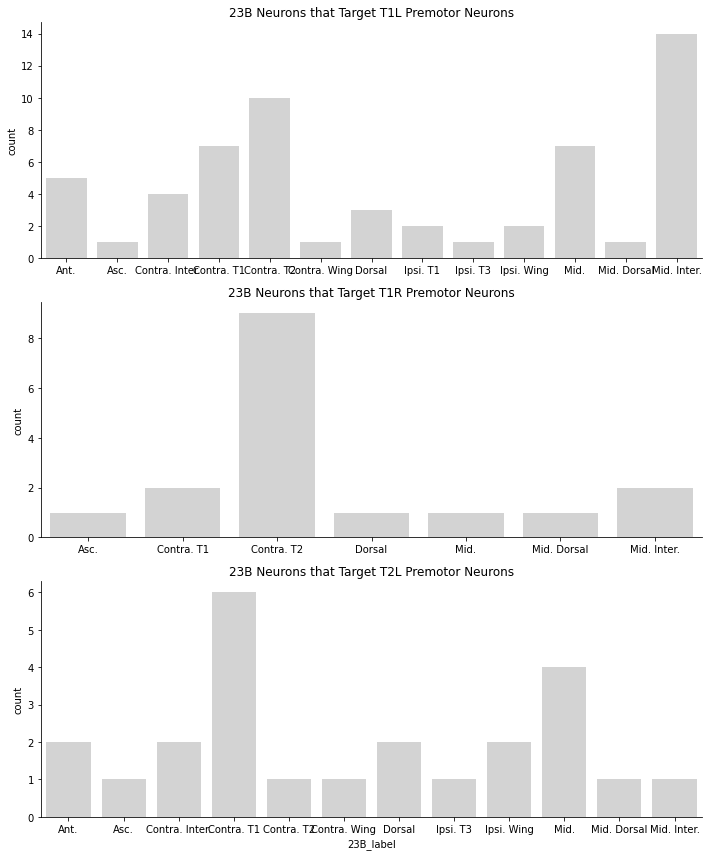

In [25]:
fig, ax = plt.subplots(3,1,figsize=(10, 12))
sub = subset.drop_duplicates(subset=['pre_pt_root_id','neuropil'])
# Ensure every 23B_label is represented in all three plots by adding empty xticks

sns.countplot(data=sub.query('neuropil=="T1L"').sort_values('23B_label'),
                x='23B_label', ax=ax[0], color='lightgray')
ax[0].set_title('23B Neurons that Target T1L Premotor Neurons')
ax[0].set_xlabel('')
sns.countplot(data=sub.query('neuropil=="T1R"').sort_values('23B_label'),x='23B_label',ax=ax[1],
              color='lightgray')
ax[1].set_title('23B Neurons that Target T1R Premotor Neurons')
ax[1].set_xlabel('')
sns.countplot(data=sub.query('neuropil=="T2L"').sort_values('23B_label'),x='23B_label',ax=ax[2],
              color='lightgray')
ax[2].set_title('23B Neurons that Target T2L Premotor Neurons')

for ax_i in ax:
    sns.despine(ax=ax_i, top=True, right=True)
plt.tight_layout()


How many neurons from each subtype contact these three premotor pools? Note that there are 14 Mid. Inter. neurons and 7 Contra. T1 neurons

/Users/leilae/anaconda3/envs/flymoves/lib/python3.7/site-packages/pandas/core/frame.py:5047: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


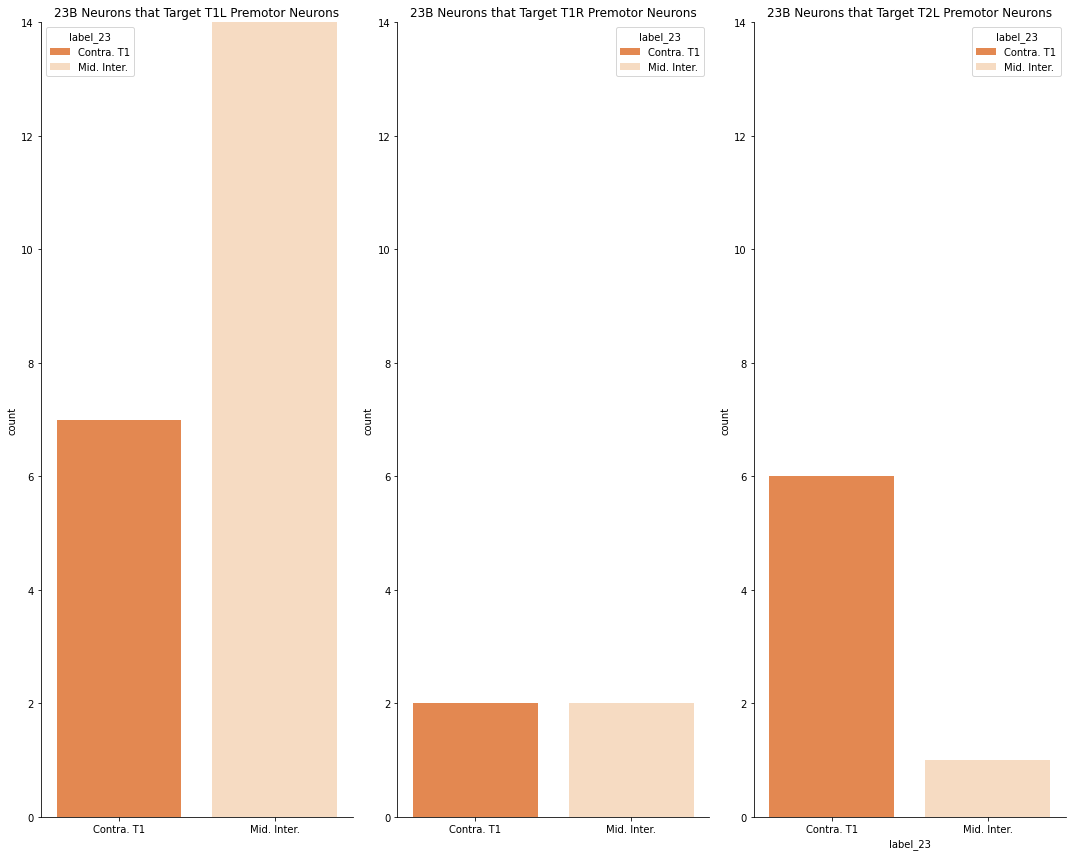

In [26]:
fig, ax = plt.subplots(1,3, figsize=(15, 12))
sub = subset.drop_duplicates(subset=['pre_pt_root_id', 'neuropil'])

# Filter the data for 23B_label == mid_inter or t1r
sub.rename(columns={'23B_label': 'label_23'}, inplace=True)
filtered_sub = sub.query('label_23 == "Mid. Inter." or label_23 == "Contra. T1"').copy()

sns.countplot(data=filtered_sub.query('neuropil=="T1L"').sort_values('label_23'),
              x='label_23', ax=ax[0], hue='label_23',
              palette=color_dict, dodge=False)
ax[0].set_title('23B Neurons that Target T1L Premotor Neurons')
ax[0].set_xlabel('')

sns.countplot(data=filtered_sub.query('neuropil=="T1R"').sort_values('label_23'),
              x='label_23', ax=ax[1], hue='label_23',
              palette=color_dict, dodge=False)
ax[1].set_title('23B Neurons that Target T1R Premotor Neurons')
ax[1].set_xlabel('')

sns.countplot(data=filtered_sub.query('neuropil=="T2L"').sort_values('label_23'),
              x='label_23', ax=ax[2], hue='label_23',
              palette=color_dict, dodge=False)
ax[2].set_title('23B Neurons that Target T2L Premotor Neurons')

for ax_i in ax:
    sns.despine(ax=ax_i, top=True, right=True)
    ax_i.set_ylim(0,14)
plt.tight_layout()



### Cord Plot of premotor connectivity

In [27]:
subset = syn_df.query('is_t1l_pm == True | is_t2l_pm == True | is_t1r_pm == True').copy()


neuropil = []
for i in subset.post_pt_root_id:
    if i in pm_t1l:
        neuropil.append('T1L')
    elif i in pm_t1r:
        neuropil.append('T1R')
    elif i in pm_t2l: 
        neuropil.append('T2L')
    else:
        neuropil.append('other')
subset['neuropil'] = neuropil
subset = subset.groupby(['23B_label','pre_pt_root_id','neuropil','post_pt_root_id']).size().reset_index(name='count')
subset = subset.query('count > 3')

In [28]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage, leaves_list

import matplotlib.pyplot as plt

subset = subset.sort_values('neuropil')
# Create a sparse matrix where rows are pre_pt_root_ids, columns are post_pt_root_ids, and values are counts

# Create a mapping for unique pre and post IDs to indices
pre_id_mapping = {id_: idx for idx, id_ in enumerate(subset['23B_label'].unique())}
post_id_mapping = {id_: idx for idx, id_ in enumerate(subset['post_pt_root_id'].unique())}

# Map pre and post IDs to their respective indices
row_indices = subset['23B_label'].map(pre_id_mapping)
col_indices = subset['post_pt_root_id'].map(post_id_mapping)

connectivity_matrix = csr_matrix(
    (subset['count'], (row_indices, col_indices)),
    shape=(len(pre_id_mapping), len(post_id_mapping))
).toarray()

# Fill missing values with 0
connectivity_matrix[np.isnan(connectivity_matrix)] = 0
cosine_sim_matrix = cosine_similarity(connectivity_matrix.T)


# Perform hierarchical clustering on the cosine similarity matrix
linkage_matrix = linkage(cosine_sim_matrix, method='ward')

# Get the order of post_pt_root_id based on clustering
ordered_indices = leaves_list(linkage_matrix)
ordered_post_ids = subset['post_pt_root_id'].unique()[ordered_indices]

# Map the ordered post_pt_root_id back to the subset DataFrame
subset['ordered_post_pt_root_id'] = subset['post_pt_root_id'].map(
    {post_id: idx for idx, post_id in enumerate(ordered_post_ids)}
)

# Sort the subset DataFrame by the ordered post_pt_root_id
subset = subset.sort_values('ordered_post_pt_root_id')

unique_post_ids = subset.sort_values(['neuropil', 'ordered_post_pt_root_id'], ascending=[True, False])['post_pt_root_id'].drop_duplicates().tolist()
# Get the unique post_pt_root_id ordered by neuropil
#unique_post_ids = subset['post_pt_root_id'].unique()

# Create a mapping of post_pt_root_id to its neuropil for coloring
neuropil_colors = {'T1L': 'slategray', 'T1R': 'lightgray', 'T2L': 'black', 'other': 'gray'}
post_id_colors = {pid: neuropil_colors.get(subset.loc[subset['post_pt_root_id'] == pid, 'neuropil'].values[0], 'gray') for pid in unique_post_ids}


(-4.80774245086444, 4.836614978682569, -4.829423884458329, 4.745757791966914)

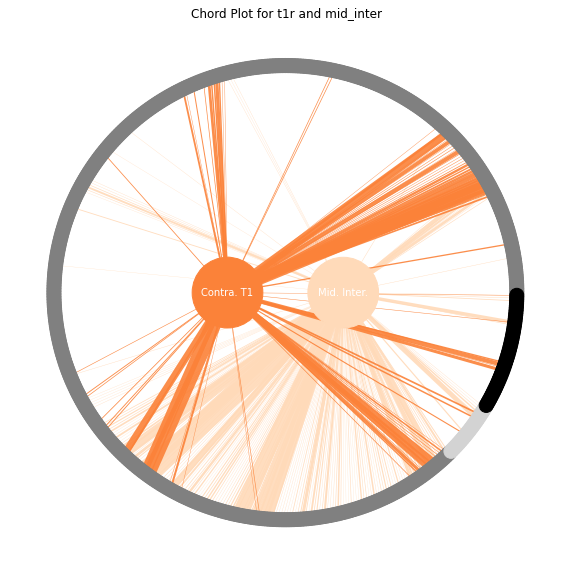

In [29]:
import networkx as nx

import matplotlib.pyplot as plt

# Filter the subset for t1r and mid_inter
t1r_subset = subset[subset['23B_label'] == 'Contra. T1']
mid_inter_subset = subset[subset['23B_label'] == 'Mid. Inter.']

# Combine the subsets for t1r and mid_inter
combined_subset = pd.concat([t1r_subset, mid_inter_subset])

neuropil_colors = {'T1L': 'gray', 'T1R': 'lightgray', 'T2L': 'black', 'other': 'gray'}
post_id_colors = {pid: neuropil_colors.get(subset.loc[subset['post_pt_root_id'] == pid, 'neuropil'].values[0], 'gray') for pid in unique_post_ids}
# Create a directed graph
G = nx.DiGraph()

# Add nodes for the inner layer (t1r and mid_inter)
inner_nodes = ['Contra. T1', 'Mid. Inter.']
G.add_nodes_from(inner_nodes, layer='inner')

# Add nodes for the outer layer (post_pt_root_ids)
post_ids = unique_post_ids
G.add_nodes_from(post_ids, layer='outer')

# Add edges for t1r
t1r_edges = t1r_subset.groupby('post_pt_root_id')['count'].sum().reset_index()
for _, row in t1r_edges.iterrows():
	G.add_edge('Contra. T1', row['post_pt_root_id'], weight=row['count'])

# Add edges for mid_inter
mid_inter_edges = mid_inter_subset.groupby('post_pt_root_id')['count'].sum().reset_index()
for _, row in mid_inter_edges.iterrows():
	G.add_edge('Mid. Inter.', row['post_pt_root_id'], weight=row['count'])

# Create positions for nodes
pos = {}
inner_circle = nx.circular_layout(G.subgraph(inner_nodes))
outer_circle = nx.circular_layout(G.subgraph(post_ids))

# Scale and shift the outer circle to be larger
for node, (x, y) in outer_circle.items():
	outer_circle[node] = (x * 4, y * 4)

# Combine positions
pos.update(inner_circle)
pos.update(outer_circle)

# Draw the graph
plt.figure(figsize=(10, 10))



# Draw edges for mid_inter
nx.draw_networkx_edges(
	G, pos, edgelist=[('Mid. Inter.', post_id) for post_id in mid_inter_edges['post_pt_root_id']],
	edge_color=color_dict['Mid. Inter.'], alpha=0.9,arrows=False,
	width=[G['Mid. Inter.'][post_id]['weight'] / 15 for post_id in mid_inter_edges['post_pt_root_id']]
)
# Draw edges for t1r
nx.draw_networkx_edges(
	G, pos, edgelist=[('Contra. T1', post_id) for post_id in t1r_edges['post_pt_root_id']],
	edge_color=color_dict['Contra. T1'], alpha=0.9,arrows=False,
	width=[G['Contra. T1'][post_id]['weight'] / 10 for post_id in t1r_edges['post_pt_root_id']]
)

# Draw nodes

nx.draw_networkx_nodes(G, pos, nodelist=inner_nodes, node_color=[color_dict[node] for node in inner_nodes], node_size=5000, label='Inner Nodes')
nx.draw_networkx_nodes(G, pos, nodelist=post_ids, node_color=[post_id_colors[pid] for pid in post_ids], node_size=200, label='Post IDs')

# Draw labels for inner nodes
nx.draw_networkx_labels(G, pos, labels={node: node for node in inner_nodes}, font_size=10, font_color='white')

plt.title('Chord Plot for t1r and mid_inter')
plt.axis('off')

